# F1 Telemetry

In [19]:
import setup
import fastf1 as f1
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Asks the user for the race year, Grand Prix, and the session type

In [20]:

while True:
    try:
        user_input = int(input("Please select a racing year: "))
        if user_input < 2018:
            print("Please select a year after 2018: ")
        else:
            year = user_input
            break
    except ValueError:
        print("Please type the year in numbers: ")

schedule = f1.get_event_schedule(year)
valid_GPs = schedule["EventName"].tolist()
print("Please select a Grand Prix from the following: ", valid_GPs)
while True:
    GP = input("Please select the Grand Prix: ").strip().title()
    if GP not in valid_GPs:
        print("Please select a valid Grand Prix: ")
    else:
        break  

valid_sessions = ["R", "Q", "FP1", "FP2", "FP3", "S"]
print("Valid sessions: ", valid_sessions)
while True:
    session_type = input("Please select a session type: ").strip().upper()
    if session_type not in valid_sessions:
        print("Please select a valid session type: ")
    else:
        break

Please select a Grand Prix from the following:  ['Pre-Season Testing', 'Bahrain Grand Prix', 'Saudi Arabian Grand Prix', 'Australian Grand Prix', 'Azerbaijan Grand Prix', 'Miami Grand Prix', 'Monaco Grand Prix', 'Spanish Grand Prix', 'Canadian Grand Prix', 'Austrian Grand Prix', 'British Grand Prix', 'Hungarian Grand Prix', 'Belgian Grand Prix', 'Dutch Grand Prix', 'Italian Grand Prix', 'Singapore Grand Prix', 'Japanese Grand Prix', 'Qatar Grand Prix', 'United States Grand Prix', 'Mexico City Grand Prix', 'São Paulo Grand Prix', 'Las Vegas Grand Prix', 'Abu Dhabi Grand Prix']
Valid sessions:  ['R', 'Q', 'FP1', 'FP2', 'FP3', 'S']


### Load Session

In [21]:

session = f1.get_session(year, GP, session_type)

session.load(telemetry=True)
print("Loaded:", session.event["EventName"])   
print("Date:", session.date)

core           INFO 	Loading data for Italian Grand Prix - Qualifying [v3.8.2]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 

Loaded: Italian Grand Prix
Date: 2023-09-02 14:00:00


### Calculations

In [22]:
"""
Loads total and clean laps
"""
all_laps = session.laps
clean_laps = all_laps[
    (all_laps["LapNumber"] > 1) &
    (all_laps["PitInTime"].isna()) &
    (all_laps["PitOutTime"].isna()) &
    (all_laps["LapTime"].notna())
].copy()
print(f"Total laps: {len(all_laps)}")
print(f"Clean laps: {len(clean_laps)}")


"""
calculate average speed, average throttle, and average brake
"""
drivers = session.laps["Driver"].unique()
results = {}
for driver in drivers:
    try:
        telemetry = clean_laps.pick_drivers(driver).get_telemetry()
        results[driver] = {  "Average speed (km/h): " : telemetry['Speed'].mean(),  "Average throttle (%): " : telemetry['Throttle'].mean(), 
                           "Average brake(%): " : telemetry['Brake'].mean() * 100}
    except Exception as e:
        print(f"No telemetry for {driver}: {e} ")
driver_summary = pd.DataFrame.from_dict(results, orient='index')
display(driver_summary)
driver_summary.columns = ["Avg Speed (km/h)", "Avg Throttle (%)", "Avg Brake (%)"]
race_avg_speed    = driver_summary["Avg Speed (km/h)"].mean()
race_avg_throttle = driver_summary["Avg Throttle (%)"].mean()
race_avg_brake    = driver_summary["Avg Brake (%)"].mean()  

""" 
Tire Degradation
"""
clean_laps["LapTimeSeconds"] = clean_laps["LapTime"].dt.total_seconds()

deg_results = {}

for (driver, stint), group in clean_laps.groupby(["Driver", "Stint"]):
    if len(group) < 3:
        continue
    
    group_sorted = group.sort_values("TyreLife")
    delta = group_sorted["LapTimeSeconds"].iloc[-1] - group_sorted["LapTimeSeconds"].iloc[0]
    
    if driver not in deg_results:
        deg_results[driver] = []
    deg_results[driver].append(delta)

deg_summary = {}
for driver, deltas in deg_results.items():
    deg_summary[driver] = round(sum(deltas) / len(deltas), 2)


race_avg_deg = round(sum(deg_summary.values()) / len(deg_summary), 2)
print(f"Race Avg Tire Degradation: {race_avg_deg} sec/stint")

Total laps: 327
Clean laps: 135


,Average speed (km/h):,Average throttle (%):,Average brake(%):
SAI,113.074968,46.666329,25.880026
VER,114.238523,36.412548,16.493728
LEC,120.000933,49.199410,26.390408
RUS,113.353815,63.358283,41.435381
PER,113.632387,37.217471,15.018301
ALB,114.517371,63.786896,43.045149
PIA,131.845263,59.950993,35.691467
HAM,113.732480,63.089806,41.631711
NOR,126.300721,62.460226,38.505547
ALO,107.969032,66.948632,40.407830


Race Avg Tire Degradation: 0.14 sec/stint


### Display


In [23]:
"""
Displaying the results
"""

print(f"== {session.event['EventName']}==")
print(f"Location: {session.event['Location']}")
print(f"Date : {session.event['EventDate']}")
print()

driver_summary["Avg Tire Deg (s)"] = pd.Series(deg_summary)
driver_summary.columns = ["Avg Speed (km/h)", "Avg Throttle (%)", "Avg Brake (%)", "Avg Tire Deg (s)"]

print("--- Race Averages ---")
print(f"Avg Speed      : {race_avg_speed} km/h")
print(f"Avg Throttle   : {race_avg_throttle} %")
print(f"Avg Brake      : {race_avg_brake} %")
print(f"Avg Tire Deg   : {race_avg_deg} sec/stint")
print()

display(driver_summary.sort_values("Avg Speed (km/h)", ascending=False).round(2))

== Italian Grand Prix==
Location: Monza
Date : 2023-09-03 00:00:00

--- Race Averages ---
Avg Speed      : 125.90059410626449 km/h
Avg Throttle   : 58.09981596967499 %
Avg Brake      : 32.669063567963505 %
Avg Tire Deg   : 0.14 sec/stint



,Avg Speed (km/h),Avg Throttle (%),Avg Brake (%),Avg Tire Deg (s)
STR,187.84,63.37,25.13,0.02
OCO,163.43,61.28,25.06,-0.03
MAG,145.32,47.73,20.36,NaN
ZHO,141.56,70.04,41.68,1.18
PIA,131.85,59.95,35.69,-0.03
HUL,126.82,61.38,33.34,-0.16
NOR,126.30,62.46,38.51,0.15
SAR,123.30,64.13,39.92,1.60
LEC,120.00,49.20,26.39,-0.50
TSU,119.79,50.96,22.95,NaN


### Display of data using SeaBorn

/var/folders/n3/lfrv_n9j0rg9lyf11_x7ln040000gn/T/ipykernel_81247/3995681002.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=driver_summary, x= driver_summary.index, y="Avg Speed (km/h)", ax=ax1, palette = "coolwarm")
/var/folders/n3/lfrv_n9j0rg9lyf11_x7ln040000gn/T/ipykernel_81247/3995681002.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=driver_summary, x= driver_summary.index, y="Avg Throttle (%)", ax=ax2, palette = "coolwarm")
/var/folders/n3/lfrv_n9j0rg9lyf11_x7ln040000gn/T/ipykernel_81247/3995681002.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` f

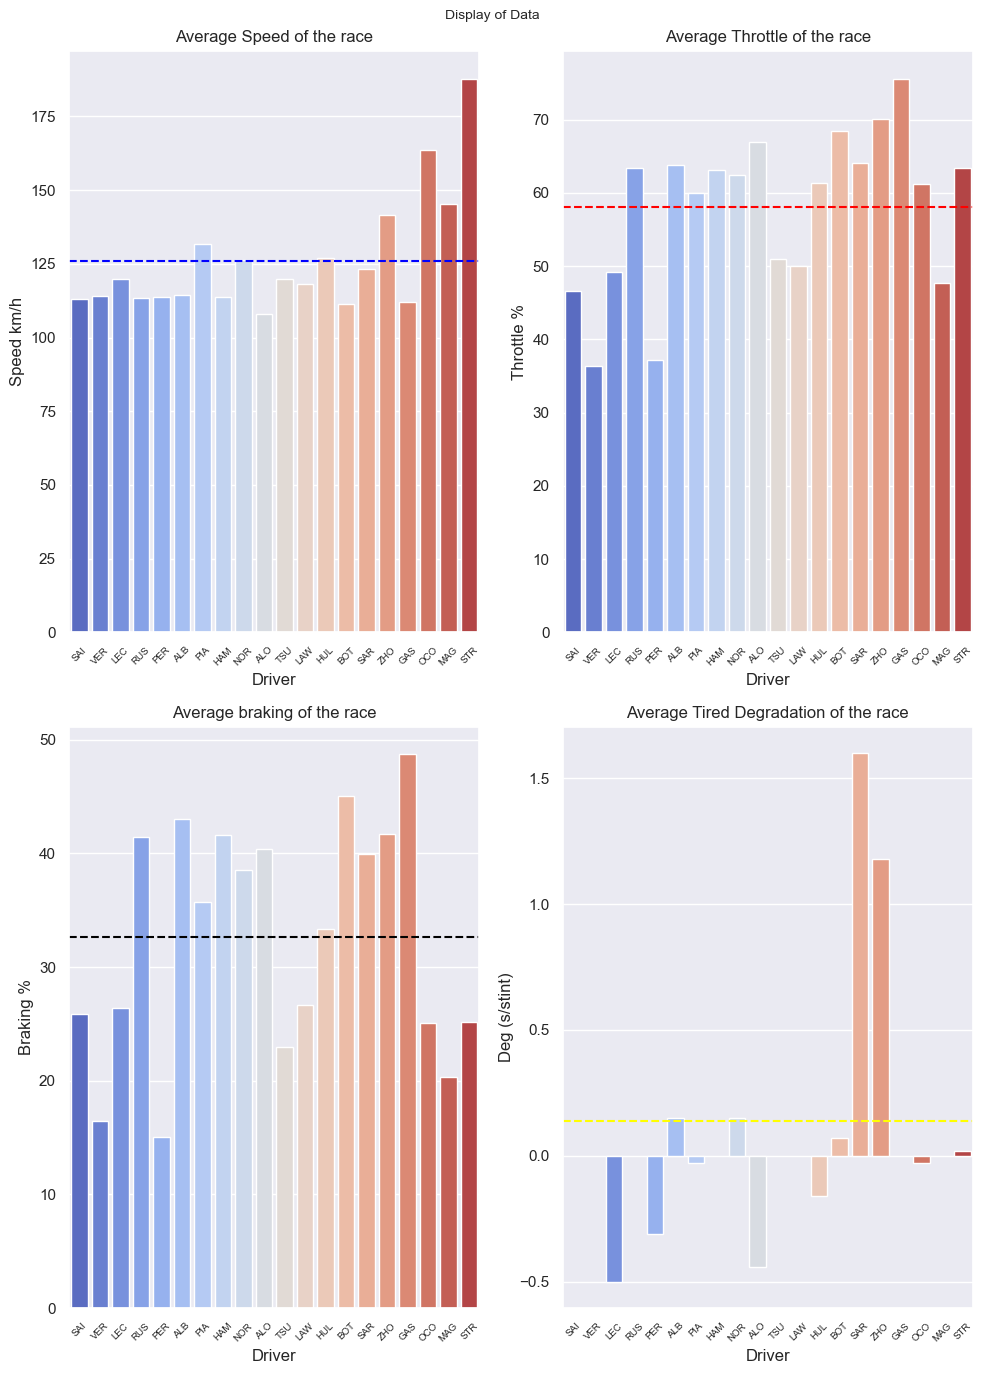

In [24]:
sns.set_theme(style="darkgrid")

fig, axes = plt.subplots(2, 2, figsize=(10, 14))
fig.suptitle(f"Display of Data", fontsize=10)

ax1 = axes[0, 0]
sns.barplot(data=driver_summary, x= driver_summary.index, y="Avg Speed (km/h)", ax=ax1, palette = "coolwarm")
ax1.axhline(race_avg_speed, color = "blue", linestyle='--', label = "Field Avg")
ax1.set_title("Average Speed of the race")
ax1.set_xlabel("Driver")
ax1.set_ylabel("Speed km/h")
ax1.tick_params(axis='x', rotation=45, labelsize=7)

ax2 = axes[0, 1]
sns.barplot(data=driver_summary, x= driver_summary.index, y="Avg Throttle (%)", ax=ax2, palette = "coolwarm")
ax2.axhline(race_avg_throttle, color = "red", linestyle='--', label = "Field Avg")
ax2.set_title("Average Throttle of the race")
ax2.set_xlabel("Driver")
ax2.set_ylabel("Throttle %")
ax2.tick_params(axis='x', rotation=45, labelsize=7)

ax3 = axes[1, 0]
sns.barplot(data=driver_summary, x= driver_summary.index, y="Avg Brake (%)", ax=ax3, palette = "coolwarm")
ax3.axhline(race_avg_brake, color = "black", linestyle='--', label = "Field Avg")
ax3.set_title("Average braking of the race")
ax3.set_xlabel("Driver")
ax3.set_ylabel("Braking %")
ax3.tick_params(axis='x', rotation=45, labelsize=7)

ax4 = axes[1, 1]
sns.barplot(data=driver_summary, x= driver_summary.index, y="Avg Tire Deg (s)", ax=ax4, palette = "coolwarm")
ax4.axhline(race_avg_deg, color = "yellow", linestyle='--', label = "Field Avg")
ax4.set_title("Average Tired Degradation of the race")
ax4.set_xlabel("Driver")
ax4.set_ylabel("Deg (s/stint)")
ax4.tick_params(axis='x', rotation=45, labelsize=7)


plt.tight_layout()
plt.show()